Instalacja potrzebnych pakietów

In [57]:
#!pip install lifelines

In [1]:
import pandas as pd

Wczytanie danych z pliku aids_data.csv

In [2]:
# read dataset from aids_data.csv
df = pd.read_csv('aids_data.csv', sep=';')

# data (as pandas dataframes)
X = df.iloc[:, :-1]  # all columns except the last as features
y = df.iloc[:, -1]   # the last column as targets

KOD 1 


In [3]:
import pandas as pd
from lifelines import WeibullAFTFitter
import matplotlib.pyplot as plt

In [4]:
print(df.columns)

Index(['time', 'trt', 'age', 'wtkg', 'hemo', 'homo', 'drugs', 'karnof',
       'oprior', 'z30', 'zprior', 'preanti', 'race', 'gender', 'str2', 'strat',
       'symptom', 'treat', 'offtrt', 'cd40', 'cd420', 'cd80', 'cd820', 'cid'],
      dtype='object')


In [5]:
# Przygotowanie danych — zachowanie wymaganych kolumn
df = df.dropna(subset=["trt", "hemo", "cd40", "age", "karnof", "gender", "homo", "drugs"])

In [6]:
# Dopasowanie modelu Weibulla
variables = ['trt', 'hemo', 'cd40', 'age', 'karnof', 'gender', 'homo', 'drugs']

# Dopasowanie modelu Weibull AFT
aft = WeibullAFTFitter()
aft.fit(df[variables + ['time', 'cid']], duration_col='time', event_col='cid')


<lifelines.WeibullAFTFitter: fitted with 2139 total observations, 1618 right-censored observations>

In [7]:
# Podsumowanie współczynników
aft.print_summary()

<lifelines.WeibullAFTFitter: fitted with 2139 total observations, 1618 right-censored observations>
             duration col = 'time'
                event col = 'cid'
   number of observations = 2139
number of events observed = 521
           log-likelihood = -4669.42
         time fit was run = 2026-03-31 10:13:52 UTC

---
                   coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param   covariate                                                                                                  
lambda_ age       -0.01      0.99      0.00           -0.01            0.00                0.99                1.00
        cd40       0.00      1.00      0.00            0.00            0.00                1.00                1.00
        drugs      0.20      1.23      0.10            0.01            0.39                1.01                1.48
        gender    -0.02      0.98      0.12           -0.25            0.20                0.78                1.22
        hemo      -0.05      0.95      0.13           -0.31            0.22                0.73                1.24
        homo      -0.06      0.94      0.10           -0.26            0.13                0.77                1.14
        karnof     0.02      1.02      0.00            0.01            0.03                1.01                1.03
        trt        0.12      1.13      0.03            0.07            0.17                1.07                1.19
        Intercept  5.03    153.68      0.46            4.13            5.94               62.43              378.29
rho_    Intercept  0.44      1.56      0.04            0.36            0.52                1.44                1.69

                   cmp to     z      p  -log2(p)
param   covariate                               
lambda_ age          0.00 -1.71   0.09      3.53
        cd40         0.00  8.81 <0.005     59.52
        drugs        0.00  2.09   0.04      4.76
        gender       0.00 -0.21   0.83      0.27
        hemo         0.00 -0.35   0.72      0.47
        homo         0.00 -0.61   0.54      0.89
        karnof       0.00  4.49 <0.005     17.07
        trt          0.00  4.60 <0.005     17.83
        Intercept    0.00 10.96 <0.005     90.37
rho_    Intercept    0.00 10.96 <0.005     90.51
---
Concordance = 0.65
AIC = 9358.83
log-likelihood ratio test = 149.05 on 8 df
-log2(p) of ll-ratio test = 91.39

KOD 2

Dopasowanie różnych modeli AFT i porównanie ich wyników

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import LogNormalAFTFitter, LogLogisticAFTFitter, WeibullAFTFitter

In [9]:
# Lista zmiennych objaśniających
variables = ['trt', 'hemo', 'cd40', 'age', 'karnof', 'gender', 'drugs', 'homo']

In [10]:
# Przygotowanie danych (upewnij się, że kolumny istnieją!)
data = df[variables + ['time', 'cid']]

In [11]:
# Modele do porównania
models = {
    "Weibull AFT": WeibullAFTFitter(),
    "Log-Logistic AFT": LogLogisticAFTFitter(),
    "Log-Normal AFT": LogNormalAFTFitter()
}

In [12]:
# Lista na wyniki
results = []

for name, model in models.items():
    model.fit(data, duration_col='time', event_col='cid')
    results.append({
        'Model': name,
        'AIC': model.AIC_,
        'Concordance': model.concordance_index_
    })

In [13]:
# Podsumowanie wyników
results_df = pd.DataFrame(results).sort_values(by='AIC')
print(results_df)

              Model          AIC  Concordance
2    Log-Normal AFT  9332.818400     0.655015
1  Log-Logistic AFT  9344.715174     0.655182
0       Weibull AFT  9358.834023     0.654933


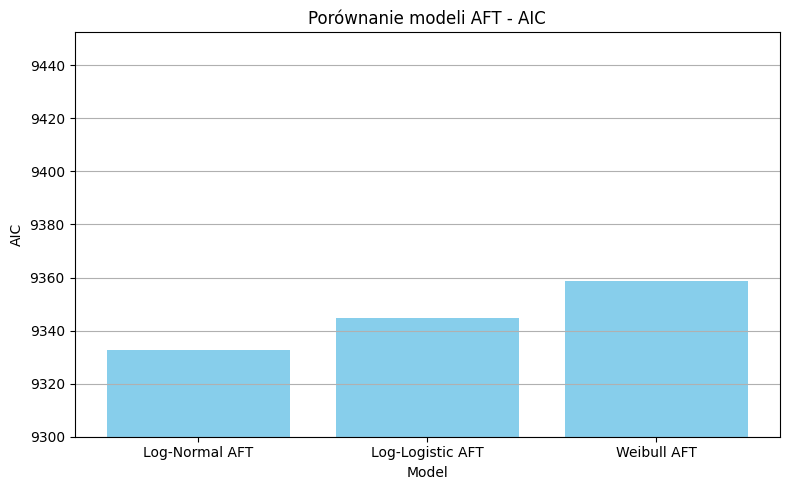

In [14]:
# Wykres AIC
plt.figure(figsize=(8, 5))
plt.bar(results_df['Model'], results_df['AIC'], color='skyblue')
plt.title('Porównanie modeli AFT - AIC')
plt.ylabel('AIC')
plt.xlabel('Model')
plt.grid(axis='y')

plt.ylim(9300, max(results_df['AIC']) * 1.01)  

plt.tight_layout()
plt.show()


KOD 3

Dopasowanie modelu log-normalnego AFT

In [15]:
import pandas as pd
from lifelines import LogNormalAFTFitter

In [16]:
# Wszystkie zmienne do modelu
all_variables = ['trt', 'hemo', 'homo', 'drugs', 'gender', 'cd40', 'age', 'karnof']
outcome_vars = ['time', 'cid']

In [17]:
# Oddzielnie: zmienne kategoryczne i liczbowe
categorical_vars = ['trt', 'hemo', 'homo', 'drugs', 'gender']
numeric_vars = ['cd40', 'age', 'karnof']

In [18]:
# Tworzenie zmiennych typu dummy tylko dla zmiennych kategorycznych
dummies = pd.get_dummies(df[categorical_vars], drop_first=True)

In [19]:
# Składanie końcowego zbioru do modelowania
model_data = pd.concat([dummies, df[numeric_vars + outcome_vars]], axis=1)

In [20]:
# Dopasowanie modelu log-normalnego AFT
aft = LogNormalAFTFitter()
aft.fit(model_data, duration_col='time', event_col='cid')

<lifelines.LogNormalAFTFitter: fitted with 2139 total observations, 1618 right-censored observations>

In [21]:
# Wyświetlenie wyników
aft.print_summary()

<lifelines.LogNormalAFTFitter: fitted with 2139 total observations, 1618 right-censored observations>
             duration col = 'time'
                event col = 'cid'
   number of observations = 2139
number of events observed = 521
           log-likelihood = -4656.41
         time fit was run = 2026-03-31 10:14:26 UTC

---
                  coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param  covariate                                                                                                  
mu_    age       -0.01      0.99      0.00           -0.01            0.00                0.99                1.00
       cd40       0.00      1.00      0.00            0.00            0.00                1.00                1.00
       drugs      0.19      1.21      0.10           -0.02            0.39                0.98                1.48
       gender    -0.05      0.95      0.13           -0.30            0.20                0.74                1.22
       hemo      -0.03      0.97      0.15           -0.32            0.27                0.72                1.31
       homo      -0.07      0.94      0.11           -0.28            0.15                0.75                1.16
       karnof     0.02      1.02      0.01            0.01            0.03                1.01                1.03
       trt        0.14      1.16      0.03            0.09            0.20                1.09                1.22
       Intercept  4.57     96.89      0.54            3.52            5.63               33.72              278.38
sigma_ Intercept  0.09      1.10      0.04            0.02            0.16                1.02                1.18

                  cmp to     z      p  -log2(p)
param  covariate                               
mu_    age          0.00 -1.90   0.06      4.12
       cd40         0.00  9.39 <0.005     67.19
       drugs        0.00  1.81   0.07      3.83
       gender       0.00 -0.41   0.68      0.55
       hemo         0.00 -0.18   0.86      0.22
       homo         0.00 -0.59   0.56      0.85
       karnof       0.00  4.47 <0.005     16.97
       trt          0.00  5.14 <0.005     21.83
       Intercept    0.00  8.49 <0.005     55.47
sigma_ Intercept    0.00  2.65   0.01      6.96
---
Concordance = 0.66
AIC = 9332.82
log-likelihood ratio test = 159.92 on 8 df
-log2(p) of ll-ratio test = 98.93

Dopasowanie modelu log-normalnego AFT z usunięciem zmiennych nieistotnych

In [22]:
import pandas as pd
from lifelines import LogNormalAFTFitter

In [23]:
# Wszystkie zmienne do modelu
all_variables = ['trt', 'drugs', 'cd40', 'age', 'karnof']
outcome_vars = ['time', 'cid']

In [24]:
# Oddzielnie: zmienne kategoryczne i liczbowe
categorical_vars = ['trt', 'drugs']
numeric_vars = ['cd40', 'age', 'karnof']

In [25]:
# Tworzenie zmiennych typu dummy tylko dla zmiennych kategorycznych
dummies = pd.get_dummies(df[categorical_vars], drop_first=True)

In [26]:
# Składanie końcowego zbioru do modelowania
model_data = pd.concat([dummies, df[numeric_vars + outcome_vars]], axis=1)

In [27]:
# Dopasowanie modelu log-normalnego AFT
aft = LogNormalAFTFitter()
aft.fit(model_data, duration_col='time', event_col='cid')

<lifelines.LogNormalAFTFitter: fitted with 2139 total observations, 1618 right-censored observations>

In [28]:
# Wyświetlenie wyników
aft.print_summary()

<lifelines.LogNormalAFTFitter: fitted with 2139 total observations, 1618 right-censored observations>
             duration col = 'time'
                event col = 'cid'
   number of observations = 2139
number of events observed = 521
           log-likelihood = -4657.31
         time fit was run = 2026-03-31 10:14:31 UTC

---
                  coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param  covariate                                                                                                  
mu_    age       -0.01      0.99      0.00           -0.01           -0.00                0.99                1.00
       cd40       0.00      1.00      0.00            0.00            0.00                1.00                1.00
       drugs      0.21      1.24      0.10            0.02            0.41                1.02                1.51
       karnof     0.02      1.02      0.01            0.01            0.03                1.01                1.03
       trt        0.14      1.15      0.03            0.09            0.20                1.09                1.22
       Intercept  4.47     87.08      0.53            3.42            5.51               30.71              246.89
sigma_ Intercept  0.09      1.10      0.04            0.02            0.16                1.02                1.18

                  cmp to     z      p  -log2(p)
param  covariate                               
mu_    age          0.00 -2.10   0.04      4.81
       cd40         0.00  9.39 <0.005     67.24
       drugs        0.00  2.13   0.03      4.93
       karnof       0.00  4.55 <0.005     17.50
       trt          0.00  5.12 <0.005     21.67
       Intercept    0.00  8.40 <0.005     54.33
sigma_ Intercept    0.00  2.66   0.01      7.00
---
Concordance = 0.66
AIC = 9328.62
log-likelihood ratio test = 158.13 on 5 df
-log2(p) of ll-ratio test = 104.99

In [29]:
import pandas as pd

# Uzyskanie podsumowania w formie DataFrame
summary_df = aft.summary

# Zapisanie do pliku Excel
summary_df.to_excel('aft_summary_results.xlsx', index=True)

print("Wyniki zostały zapisane do pliku 'aft_summary_results.xlsx'")


Wyniki zostały zapisane do pliku 'aft_summary_results.xlsx'


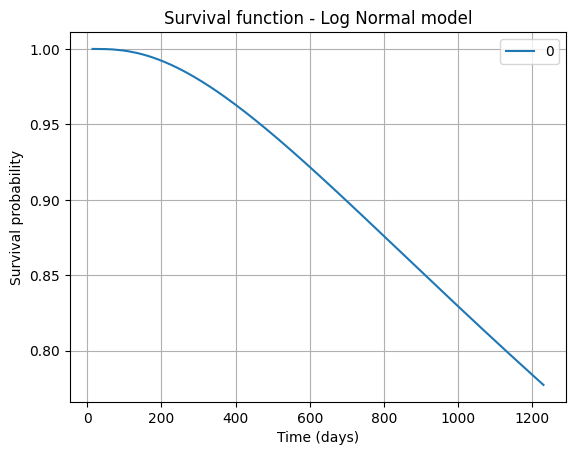

In [30]:
# Przykładowa funkcja przeżycia dla pierwszego rekordu
surv_func = aft.predict_survival_function(df.iloc[0:1])
surv_func.plot(title="Survival function - Log Normal model")
plt.xlabel("Time (days)")
plt.ylabel("Survival probability")
plt.grid(True)
plt.show()

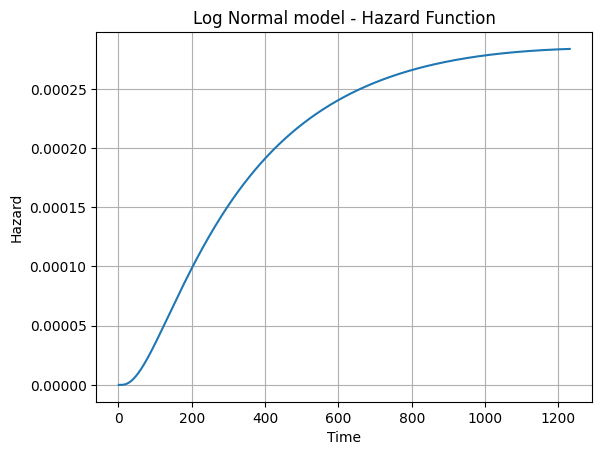

In [31]:
from lifelines import LogNormalAFTFitter
import numpy as np
import matplotlib.pyplot as plt

# Funkcja hazardu na podstawie funkcji przeżycia
def hazard_function(aft, t_values, df):
    # Obliczanie funkcji przeżycia dla różnych czasów
    surv_func = aft.predict_survival_function(df.iloc[0:1], times=t_values)
    survival_values = surv_func.values.flatten()  # Ekstrakcja wartości funkcji przeżycia
    
    # Obliczanie hazardu
    hazard = -np.gradient(np.log(survival_values), t_values)
    return hazard

# Określenie wartości czasów
t_values = np.linspace(1, max(df['time']), 1200)

# Obliczenie hazardu
hazard_values = hazard_function(aft, t_values, df)

# Wykres funkcji hazardu
plt.plot(t_values, hazard_values)
plt.title('Log Normal model - Hazard Function')
plt.xlabel('Time')
plt.ylabel('Hazard')
plt.grid(True)
plt.show()


In [32]:
import pandas as pd

# Zakładam, że masz dopasowany model 'aft' (np. WeibullAFTFitter)
# Po dopasowaniu modelu AFT, uzyskujemy macierz kowariancji:
cov_matrix = aft.variance_matrix_

# Konwersja macierzy kowariancji do DataFrame (czytelniejszy format)
cov_matrix_df = pd.DataFrame(cov_matrix)

# Zapisanie macierzy kowariancji do pliku Excel
cov_matrix_df.to_excel('covariance_matrix.xlsx', index=True)

print("Macierz kowariancji została zapisana do pliku 'covariance_matrix.xlsx'")


Macierz kowariancji została zapisana do pliku 'covariance_matrix.xlsx'


In [33]:
# Macierz kowariancji współczynników (jak COVB w SAS)
print("\nMacierz kowariancji (COVB):")
print(aft.variance_matrix_)


Macierz kowariancji (COVB):
param                      mu_                                            \
covariate                  age          cd40         drugs        karnof   
param  covariate                                                           
mu_    age        1.289361e-05  2.362160e-09 -2.091558e-05  1.669447e-06   
       cd40       2.362160e-09  8.699314e-08  4.934398e-07 -9.089769e-08   
       drugs     -2.091558e-05  4.934398e-07  9.994641e-03  4.639642e-05   
       karnof     1.669447e-06 -9.089769e-08  4.639642e-05  2.765463e-05   
       trt       -7.056759e-07  4.886919e-07 -2.183496e-05  4.978608e-06   
       Intercept -6.265979e-04 -1.859232e-05 -4.700747e-03 -2.648644e-03   
sigma_ Intercept -8.435058e-06  2.238601e-06  2.443052e-04  1.892419e-05   

param                                       sigma_  
covariate                  trt Intercept Intercept  
param  covariate                                    
mu_    age       -7.056759e-07 -0.000627 -0.000008 

KOD 4 - Cenzurowanie lewo i prawostronne


W badaniu ACTG175 dotyczącym pacjentów z HIV występuje **prawostronne cenzorowanie (right censoring)**, które ma miejsce, gdy pacjent nie doświadczył zdarzenia (np. spadku liczby CD4, rozwoju AIDS lub zgonu) w czasie trwania obserwacji — wiemy, że przeżył co najmniej do momentu zakończenia badania, ale nie wiemy, co stało się później. **Lewostronne cenzorowanie (left censoring)** nie występuje w tym badaniu, ponieważ moment rozpoczęcia obserwacji (czyli włączenie do badania) jest dokładnie znany i żaden pacjent nie miał zdarzenia przed tym momentem. W związku z tym do analizy wystarczy uwzględnić prawostronne cenzorowanie, które jest domyślnie obsługiwane przez modele przeżycia po przekazaniu kolumn `time` i `status`.



KOD 5 - Cenzurowanie interwałowe

Nie jest konieczne albowiem wiemy dokładnie kiedy zdarzenie miało miejsce (pomimo tego, że w badaniu wizyty odbywały się najczęściej co 12 tygodni to zapis wszystkich wydarzeń jest w dniach, przez co dokładnie wiemy kiedy możliwe zdarzenie 1 miało miejsce)

KOD 6 - Obliczenie mediany oraz jej odchylenia standardowego

In [ ]:
import pandas as pd
import numpy as np
from lifelines import LogNormalAFTFitter

# Usunięcie braków danych
model_data_clean = model_data.dropna()

# Dopasowanie modelu Log-Normal AFT do pełnych danych
aft = LogNormalAFTFitter()
aft.fit(model_data_clean, duration_col='time', event_col='cid')

# Predykcja mediany z głównego modelu
mediany = aft.predict_median(model_data_clean)

# Bootstrap
n_iterations = 100
all_medians = []

for i in range(n_iterations):
    # losowanie z powtórzeniami i resetowanie indeksu
    sample = model_data_clean.sample(frac=1, replace=True).reset_index(drop=True)
    
    aft_bs = LogNormalAFTFitter()
    aft_bs.fit(sample, duration_col='time', event_col='cid')
    
    pred = aft_bs.predict_median(model_data_clean)
    all_medians.append(pred)

# Łączenie wyników bootstrapu
bootstrap_df = pd.concat(all_medians, axis=1)
stds = bootstrap_df.std(axis=1)

# Tworzenie końcowego DataFrame
wyniki = pd.DataFrame({
    "Mediana": mediany,
    "Odchylenie standardowe": stds
})

print(wyniki)
